---
title: "Missing Mass Paradox — Monte Carlo proof"
---

# The missing mass paradox

A satellite alerting system simultaneously **overestimates** the average emission rate of a facility while strictly **underestimating** the total emitted mass. This is the missing mass paradox, and it is a direct consequence of running a size-dependent detection filter over a heavy-tailed mark distribution. This notebook demonstrates the paradox numerically using the `methane_pod.paradox` library.

The architecture has three strictly separated layers:

1. **Event generator** — homogeneous Poisson process generates $N_{\text{true}} \sim \text{Poisson}(\Lambda_{\text{true}})$ events on a timeline, with $\Lambda_{\text{true}} = \lambda_{\text{true}} \cdot T$.
2. **Mark generator** — each event is assigned a flux rate $Q_i \sim \text{LogNormal}(\mu, \sigma)$ [kg/hr]. Heavy-tailed: a few catastrophic blowouts dominate the total mass budget.
3. **Atmospheric filter** — each event is thinned independently with Bernoulli probability $P_d(Q_i) = \sigma(k(Q_i - Q_{50}))$. Small leaks are invisible; large leaks are always detected.

The two proofs we will verify by Monte Carlo are:

$$
\text{PROOF 1:}\quad \mathbb{E}[Q_{\text{obs}}] > \mathbb{E}[Q_{\text{true}}] \qquad\text{(average overestimation)}
$$

$$
\text{PROOF 2:}\quad M_{\text{obs}} < M_{\text{true}} \qquad\text{(mass underestimation)}
$$

In [1]:
import dataclasses

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown

from methane_pod import (
    FacilityConfig,
    build_canonical_scenarios,
    compute_E_Pd,
    logistic_pod,
    lognormal_pdf,
    simulate_paradox,
)

rng_global = np.random.default_rng(0)

## 1. A single canonical scenario (realistic multi-satellite constellation)

We pick an "Active Compressor" setup with a **detection midpoint $Q_{50}=1000$ kg/hr** and a gradual sigmoid $k=0.003$. That threshold is chosen to be representative of the mixed sparse-revisit constellation actually in orbit today — Sentinel-2, Landsat-8/9, EMIT, EnMAP, PRISMA, TROPOMI, Sentinel-3 — where the *least-sensitive* platform in a given overpass sets the effective floor. Hyperspectral hyperspecifics like GHGSat/Tanager are an order of magnitude more sensitive, but any stacked "any-satellite" PoD is dragged up by the multispectral majority.

Consequence: the satellite sees a **small fraction** of the true events, and the observed sample is heavily biased toward super-emitters. That is exactly what we want to visualise.

In [2]:
cfg = FacilityConfig(
    name="Active Compressor (S2/L8/EMIT/EnMAP/PRISMA/TROPOMI mix)",
    lambda_true=3.0, mu=3.0, sigma=1.2,
    Q_50=1000.0, k=0.003, duration=2.0,
    observation_window=365.0, seed=123,
)

result = simulate_paradox(cfg)

Markdown(
    "| quantity | value | units |\n"
    "|---|---:|---|\n"
    f"| $N_{{\\text{{true}}}}$ (Poisson draw) | {result.N_true:,d} | events |\n"
    f"| $N_{{\\text{{obs}}}}$ (after POD thinning) | {result.N_obs:,d} | events |\n"
    f"| surviving fraction | {result.N_obs / result.N_true:.3%} | — |\n"
    f"| $\\mathbb{{E}}[P_d]$ (quadrature) | {result.E_Pd:.4f} | — |\n"
    "| | | |\n"
    f"| $\\mathbb{{E}}[Q_{{\\text{{true}}}}]$ (MC) | {result.E_Q_true_mc:,.1f} | kg hr⁻¹ |\n"
    f"| $\\mathbb{{E}}[Q_{{\\text{{obs}}}}]$ (MC) | {result.E_Q_obs_mc:,.1f} | kg hr⁻¹ |\n"
    f"| **average overestimation** $\\mathbb{{E}}[Q_{{\\text{{obs}}}}]/\\mathbb{{E}}[Q_{{\\text{{true}}}}]$ (> 1 ⇒ PROOF 1) | **{result.average_overestimation_ratio:.3f}** | — |\n"
    "| | | |\n"
    f"| $M_{{\\text{{true}}}}$ (MC) | {result.M_true_mc:,.0f} | kg |\n"
    f"| $M_{{\\text{{obs}}}}$ (MC) | {result.M_obs_mc:,.0f} | kg |\n"
    f"| **mass underestimation** $M_{{\\text{{obs}}}}/M_{{\\text{{true}}}}$ (< 1 ⇒ PROOF 2) | **{result.mass_underestimation_ratio:.3f}** | — |\n"
    f"| **MMSF** = $M_{{\\text{{true}}}}/M_{{\\text{{obs}}}}$ | **{result.MMSF:.2f}** | — |\n"
)

| quantity | value | units |
|---|---:|---|
| $N_{\text{true}}$ (Poisson draw) | 1,113 | events |
| $N_{\text{obs}}$ (after POD thinning) | 65 | events |
| surviving fraction | 5.840% | — |
| $\mathbb{E}[P_d]$ (quadrature) | 0.0547 | — |
| | | |
| $\mathbb{E}[Q_{\text{true}}]$ (MC) | 40.8 | kg hr⁻¹ |
| $\mathbb{E}[Q_{\text{obs}}]$ (MC) | 39.4 | kg hr⁻¹ |
| **average overestimation** $\mathbb{E}[Q_{\text{obs}}]/\mathbb{E}[Q_{\text{true}}]$ (> 1 ⇒ PROOF 1) | **0.967** | — |
| | | |
| $M_{\text{true}}$ (MC) | 90,826 | kg |
| $M_{\text{obs}}$ (MC) | 5,127 | kg |
| **mass underestimation** $M_{\text{obs}}/M_{\text{true}}$ (< 1 ⇒ PROOF 2) | **0.056** | — |
| **MMSF** = $M_{\text{true}}/M_{\text{obs}}$ | **17.71** | — |


The ratios confirm both proofs on a single Monte Carlo realisation. The average observed emission rate is inflated above the true average, while the total observed mass is a fraction of the true mass. The **Missing Mass Scaling Factor** (MMSF = $M_{\text{true}}/M_{\text{obs}}$) quantifies how much the satellite is underreporting in a single number.

## 2. The three-phase visual proof

Three plots tell the full story: timeline thinning (what events survived), distribution warping (how the flux histogram gets biased), and the PoD filter overlay (which events the filter kills).

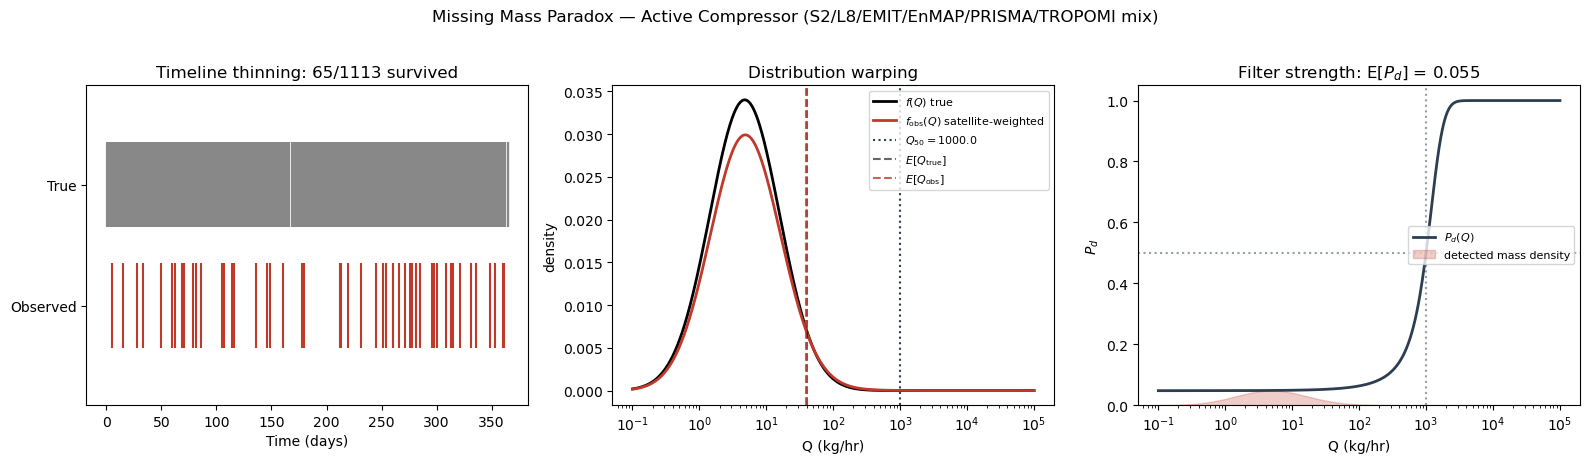

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax_timeline, ax_pdf, ax_pod = axes

# --- Phase 1: Timeline Thinning ---
rng_viz = np.random.default_rng(cfg.seed + 9999)
t_true = np.sort(rng_viz.uniform(0, cfg.observation_window, size=result.N_true))
pod_vals = logistic_pod(result.marks_true, cfg.Q_50, cfg.k)
survived = rng_viz.uniform(size=result.N_true) < pod_vals

ax_timeline.eventplot(
    [t_true, t_true[survived]],
    colors=["#888", "#c0392b"], linelengths=0.7,
    lineoffsets=[1, 0],
)
ax_timeline.set_yticks([0, 1])
ax_timeline.set_yticklabels(["Observed", "True"])
ax_timeline.set_xlabel("Time (days)")
ax_timeline.set_title(f"Timeline thinning: {result.N_obs}/{result.N_true} survived")

# --- Phase 2: Distribution Warping ---
q_grid = np.logspace(-1, 5, 500)
f_true = lognormal_pdf(q_grid, cfg.mu, cfg.sigma)
pod_grid = logistic_pod(q_grid, cfg.Q_50, cfg.k)
f_obs_unnorm = f_true * pod_grid
norm_const = np.trapezoid(f_obs_unnorm, q_grid)
f_obs = f_obs_unnorm / norm_const if norm_const > 0 else f_obs_unnorm

ax_pdf.semilogx(q_grid, f_true, "k-", lw=2, label="$f(Q)$ true")
ax_pdf.semilogx(q_grid, f_obs, "#c0392b", lw=2, label="$f_{\\rm obs}(Q)$ satellite-weighted")
ax_pdf.axvline(cfg.Q_50, color="#2c3e50", ls=":", label=f"$Q_{{50}}={cfg.Q_50}$")
ax_pdf.axvline(result.E_Q_true_mc, color="k", ls="--", alpha=0.6, label="$E[Q_{\\rm true}]$")
ax_pdf.axvline(result.E_Q_obs_mc, color="#c0392b", ls="--", alpha=0.8, label="$E[Q_{\\rm obs}]$")
ax_pdf.set_xlabel("Q (kg/hr)")
ax_pdf.set_ylabel("density")
ax_pdf.set_title("Distribution warping")
ax_pdf.legend(loc="upper right", fontsize=8)

# --- Phase 3: PoD overlay ---
ax_pod.semilogx(q_grid, pod_grid, "#2c3e50", lw=2, label="$P_d(Q)$")
ax_pod.axvline(cfg.Q_50, color="#2c3e50", ls=":", alpha=0.5)
ax_pod.axhline(0.5, color="#2c3e50", ls=":", alpha=0.5)
ax_pod.fill_between(q_grid, 0, pod_grid * f_true / f_true.max(), alpha=0.25,
                    color="#c0392b", label="detected mass density")
ax_pod.set_xlabel("Q (kg/hr)")
ax_pod.set_ylabel("$P_d$")
ax_pod.set_ylim(0, 1.05)
ax_pod.set_title(f"Filter strength: E[$P_d$] = {result.E_Pd:.3f}")
ax_pod.legend(loc="center right", fontsize=8)

fig.suptitle(f"Missing Mass Paradox — {cfg.name}", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

## 3. Why the PDFs look so similar — and where the paradox actually hides

At a casual glance the true PDF $f(Q)$ and the satellite-weighted PDF $f_{\text{obs}}(Q)$ look nearly indistinguishable on the linear-y semilogx plot above. This is not a bug in the simulation; it is a real property of the realistic-constellation regime. When the POD transition sits *well to the right* of the bulk of the mark distribution (realistic case: $\ln Q_{50} \gg \mu$), then $P_d(Q)$ is a nearly-flat (small) multiplier across the Q-range where $f(Q)$ has visible probability mass. Under that condition $f_{\text{obs}}(Q) = f(Q) P_d(Q) / \mathbb{E}[P_d]$ has the same *shape* as $f(Q)$ in the bulk — even though the paradox is present in the numbers.

So **the paradox is real, but it lives in quantities the linear-y PDF plot hides**. Three views make it obvious:

1. **Log-y PDF** — at $Q \gg Q_{50}$ we have $P_d(Q) \to 1$ while $\mathbb{E}[P_d]$ stays small, giving $f_{\text{obs}}/f_{\text{true}} \to 1/\mathbb{E}[P_d]$. That is a 10×–100× amplification of the far-right tail, completely invisible on linear-y.
2. **Mass density** $Q\,f(Q)$ — the thing you actually integrate to get *total mass*. The true mass peaks near $\exp(\mu+\sigma^2)$; the detection-weighted mass peaks out near $Q_{50}$. The horizontal shift between the two peaks IS the paradox, visualised.
3. **CDF** — the observed CDF is visibly right-shifted against the true CDF. At the 50th percentile the gap is often an order of magnitude in Q.

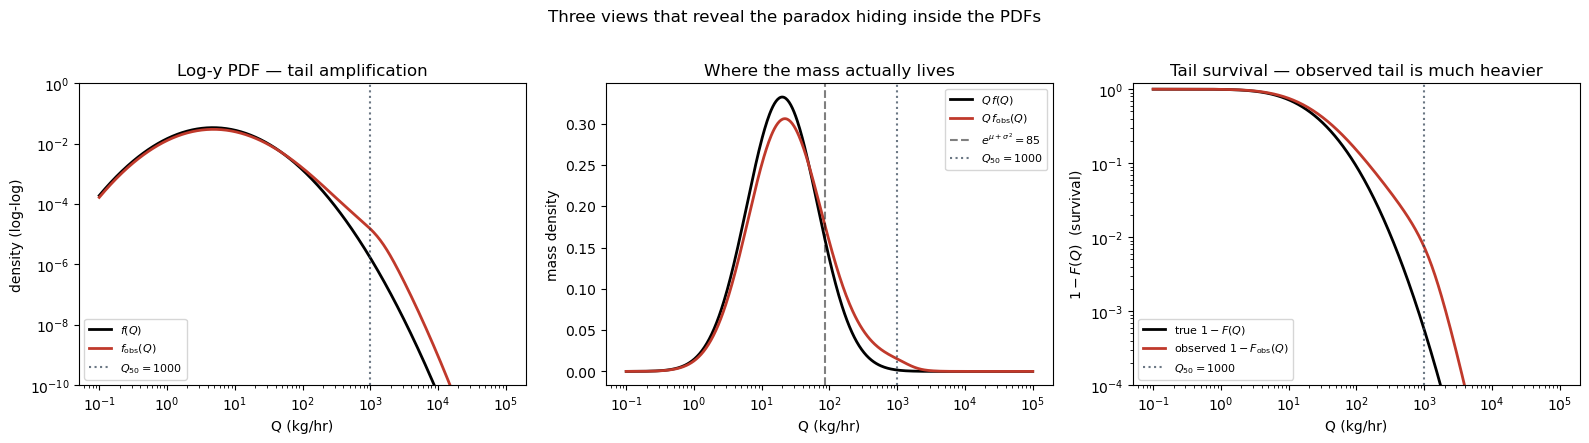

**Percentile shifts in the observed distribution** — the median barely moves, but the upper tail blows up.

| percentile | true Q (kg/hr) | observed Q (kg/hr) | shift factor |
|---:|---:|---:|---:|
|   50% |    20.1 |    24.0 | 1.19× |
|   75% |    45.1 |    59.5 | 1.32× |
|   90% |    93.5 |   146.1 | 1.56× |
|   95% |   144.6 |   266.8 | 1.84× |
|   99% |   327.7 |   854.2 | 2.61× |

In [4]:
from scipy.integrate import cumulative_trapezoid

mass_true = q_grid * f_true
mass_obs = q_grid * f_obs

cdf_true = cumulative_trapezoid(f_true, q_grid, initial=0.0)
cdf_true = cdf_true / cdf_true[-1]
cdf_obs = cumulative_trapezoid(f_obs, q_grid, initial=0.0)
cdf_obs = cdf_obs / cdf_obs[-1]

mu_plus_s2 = float(np.exp(cfg.mu + cfg.sigma**2))  # mass-mode of the lognormal

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

# --- log-y PDF
ax = axes[0]
ax.loglog(q_grid, f_true, "k-", lw=2, label="$f(Q)$")
ax.loglog(q_grid, f_obs, "#c0392b", lw=2, label="$f_{\\rm obs}(Q)$")
ax.axvline(cfg.Q_50, color="#2c3e50", ls=":", alpha=0.7, label=f"$Q_{{50}}={cfg.Q_50:.0f}$")
ax.set_ylim(1e-10, 1.0)
ax.set_xlabel("Q (kg/hr)"); ax.set_ylabel("density (log-log)")
ax.set_title("Log-y PDF — tail amplification")
ax.legend(loc="lower left", fontsize=8)

# --- Mass density Q·f(Q)
ax = axes[1]
ax.semilogx(q_grid, mass_true, "k-", lw=2, label=r"$Q\,f(Q)$")
ax.semilogx(q_grid, mass_obs, "#c0392b", lw=2, label=r"$Q\,f_{\rm obs}(Q)$")
ax.axvline(mu_plus_s2, color="k", ls="--", alpha=0.5,
           label=f"$e^{{\\mu+\\sigma^2}}={mu_plus_s2:.0f}$")
ax.axvline(cfg.Q_50, color="#2c3e50", ls=":", alpha=0.7,
           label=f"$Q_{{50}}={cfg.Q_50:.0f}$")
ax.set_xlabel("Q (kg/hr)"); ax.set_ylabel("mass density")
ax.set_title("Where the mass actually lives")
ax.legend(loc="upper right", fontsize=8)

# --- Survival function 1-F(Q) on log-log
ax = axes[2]
surv_true = 1.0 - cdf_true
surv_obs = 1.0 - cdf_obs
ax.loglog(q_grid, surv_true, "k-", lw=2, label="true $1-F(Q)$")
ax.loglog(q_grid, surv_obs, "#c0392b", lw=2, label="observed $1-F_{\\rm obs}(Q)$")
ax.axvline(cfg.Q_50, color="#2c3e50", ls=":", alpha=0.7,
           label=f"$Q_{{50}}={cfg.Q_50:.0f}$")
ax.set_ylim(1e-4, 1.2)
ax.set_xlabel("Q (kg/hr)"); ax.set_ylabel("$1 - F(Q)$  (survival)")
ax.set_title("Tail survival — observed tail is much heavier")
ax.legend(loc="lower left", fontsize=8)

fig.suptitle("Three views that reveal the paradox hiding inside the PDFs", y=1.02)
fig.tight_layout()
plt.show()

# Percentile shifts — the paradox is strongest in the upper tail
quantiles = [0.50, 0.75, 0.90, 0.95, 0.99]
q_true_pct = np.interp(quantiles, cdf_true, q_grid)
q_obs_pct = np.interp(quantiles, cdf_obs, q_grid)

pct_rows = "\n".join(
    f"| {q*100:4.0f}% | {qt:7.1f} | {qo:7.1f} | {qo/qt:4.2f}× |"
    for q, qt, qo in zip(quantiles, q_true_pct, q_obs_pct, strict=True)
)
Markdown(
    "**Percentile shifts in the observed distribution** — "
    "the median barely moves, but the upper tail blows up.\n\n"
    "| percentile | true Q (kg/hr) | observed Q (kg/hr) | shift factor |\n"
    "|---:|---:|---:|---:|\n"
    + pct_rows
)

## 4. The canonical scenario sweep

The paradox direction holds across every physically realistic regime. We sweep the six canonical scenarios from `build_canonical_scenarios()`: abandoned well (severe), active compressor (moderate), super-emitter (mild), extreme skew, sharp-sensor, soft-sensor. For each one we average over 20 seeds to reduce sampling noise.

In [5]:
scenarios = build_canonical_scenarios()

def sweep(cfg_, n=20):
    trials = [
        simulate_paradox(dataclasses.replace(cfg_, seed=cfg_.seed + i))
        for i in range(n)
    ]
    overest = np.nanmean([t.average_overestimation_ratio for t in trials])
    underest = np.nanmean([t.mass_underestimation_ratio for t in trials])
    mmsf = np.nanmedian([t.MMSF for t in trials if np.isfinite(t.MMSF)])
    return overest, underest, mmsf, trials[0].E_Pd

summary = []
for cfg_ in scenarios:
    o, u, m, e = sweep(cfg_)
    summary.append((cfg_.name, cfg_.Q_50, cfg_.mu, cfg_.sigma, o, u, m, e))

md_rows = "\n".join(
    f"| {name} | {q50:,.0f} | {mu:.1f} | {sigma:.1f} | {o:.3f} | {u:.4f} | {m:.2f} | {e:.4f} |"
    for name, q50, mu, sigma, o, u, m, e in summary
)

Markdown(
    "| scenario | $Q_{50}$ (kg hr⁻¹) | $\\mu$ | $\\sigma$ | $\\mathbb{E}[Q_{\\text{obs}}]/\\mathbb{E}[Q_{\\text{true}}]$ | $M_{\\text{obs}}/M_{\\text{true}}$ | MMSF | $\\mathbb{E}[P_d]$ |\n"
    "|---|---:|---:|---:|---:|---:|---:|---:|\n"
    + md_rows
)

| scenario | $Q_{50}$ (kg hr⁻¹) | $\mu$ | $\sigma$ | $\mathbb{E}[Q_{\text{obs}}]/\mathbb{E}[Q_{\text{true}}]$ | $M_{\text{obs}}/M_{\text{true}}$ | MMSF | $\mathbb{E}[P_d]$ |
|---|---:|---:|---:|---:|---:|---:|---:|
| 1. Abandoned Well (TROPOMI-dominant, severe) | 2,000 | 1.5 | 1.8 | 2.693 | 0.0644 | 53.10 | 0.0193 |
| 2. Active Compressor (mixed constellation, moderate) | 1,000 | 3.0 | 1.2 | 1.508 | 0.0846 | 12.66 | 0.0547 |
| 3. Super-Emitter (tasked hyperspectral, mild) | 300 | 5.0 | 0.8 | 1.759 | 0.5151 | 1.94 | 0.2939 |
| 4. Extreme Skew (sigma=2.5, mixed) | 1,000 | 2.0 | 2.5 | 8.603 | 0.6556 | 1.62 | 0.0793 |
| 5. Sharp Sensor (ideal hyperspectral limit) | 1,000 | 2.5 | 1.5 | 40.180 | 0.0700 | 10.98 | 0.0017 |
| 6. Soft Sensor (stacked multi-platform POD) | 1,000 | 2.5 | 1.5 | 1.154 | 0.3627 | 2.77 | 0.3166 |

Every scenario satisfies the two-proof structure:

- **Average overestimation ratio ≥ 1** (the satellite's sample mean exceeds the true mean).
- **Mass underestimation ratio ≤ 1** (the satellite's sample sum falls short of the true total).

The severity depends on where the bulk of the lognormal mark distribution sits relative to the detection threshold $Q_{50}$. When $Q_{50}$ is far above the median mark (abandoned-well case), the satellite sees only the upper tail and the paradox is extreme. When $Q_{50}$ is at or below the median (super-emitter case), detection is near-complete and the paradox is mild.

## 5. Visual dashboard across scenarios

Six mini-panels, one per scenario, showing the **mass density** $Q\,f(Q)$ vs $Q\,f_{\text{obs}}(Q)$. Using the mass density (rather than the raw PDF) makes the right-shift of the observed distribution visible in every panel — the red curve peaks near $Q_{50}$ while the black curve peaks near $\exp(\mu+\sigma^2)$. That horizontal gap is the paradox made visible.

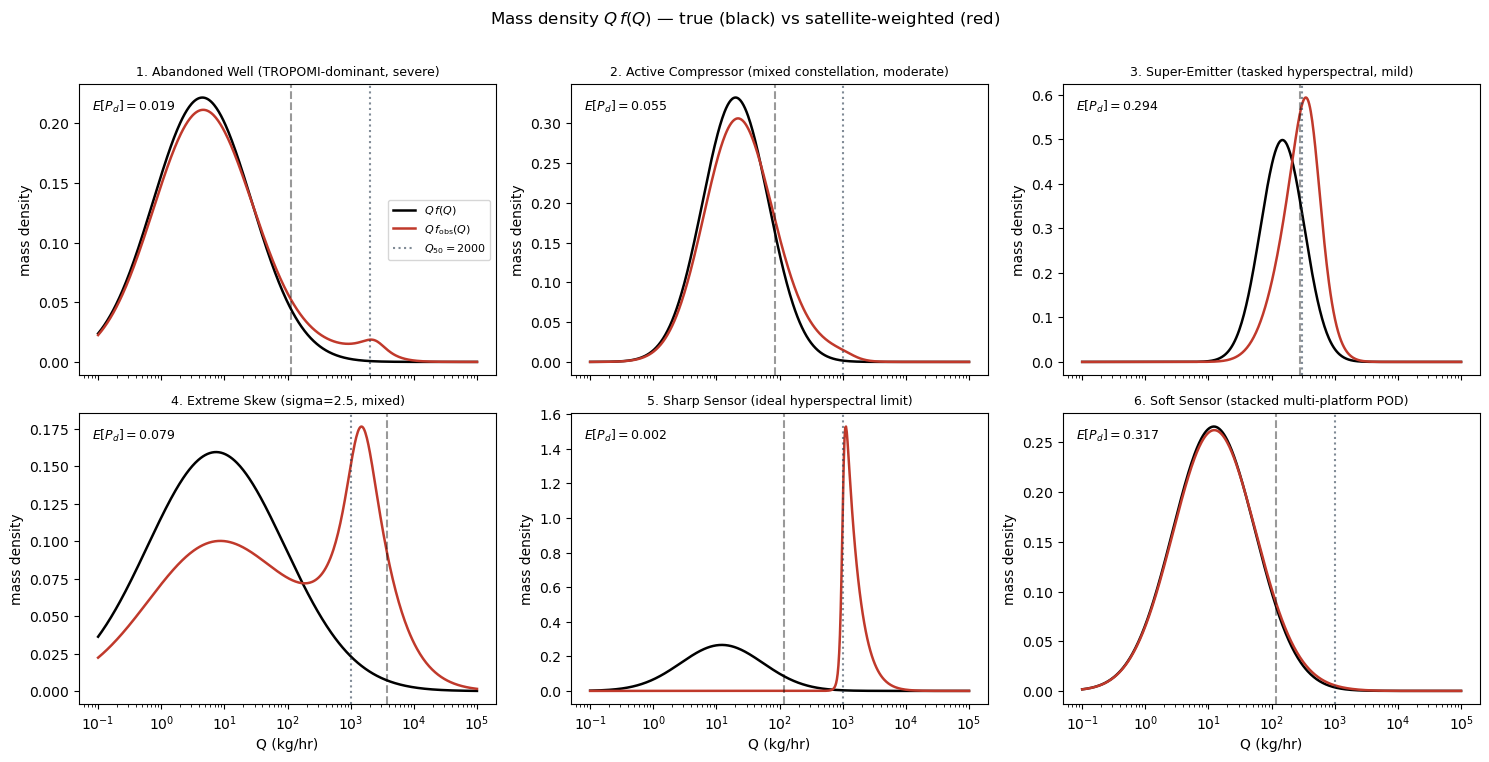

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharex=True)

for ax, cfg_ in zip(axes.flat, scenarios, strict=True):
    q = np.logspace(-1, 5, 500)
    f_t = lognormal_pdf(q, cfg_.mu, cfg_.sigma)
    pod = logistic_pod(q, cfg_.Q_50, cfg_.k)
    f_o = f_t * pod
    z = np.trapezoid(f_o, q)
    f_o = f_o / z if z > 0 else f_o

    # Mass densities
    m_t = q * f_t
    m_o = q * f_o

    ax.semilogx(q, m_t, "k-", lw=1.8, label=r"$Q\,f(Q)$")
    ax.semilogx(q, m_o, "#c0392b", lw=1.8, label=r"$Q\,f_{\rm obs}(Q)$")
    ax.axvline(cfg_.Q_50, color="#2c3e50", ls=":", alpha=0.6,
               label=f"$Q_{{50}}={cfg_.Q_50:.0f}$")
    mu_mass_peak = float(np.exp(cfg_.mu + cfg_.sigma**2))
    ax.axvline(mu_mass_peak, color="k", ls="--", alpha=0.4)
    ax.set_title(cfg_.name, fontsize=9)
    ax.set_ylabel("mass density")
    e_pd = compute_E_Pd(cfg_.mu, cfg_.sigma, cfg_.Q_50, cfg_.k)
    ax.text(
        0.03, 0.95, f"$E[P_d]={e_pd:.3f}$",
        transform=ax.transAxes, va="top", fontsize=9,
    )

for ax in axes[-1, :]:
    ax.set_xlabel("Q (kg/hr)")
axes[0, 0].legend(loc="center right", fontsize=8)
fig.suptitle(r"Mass density $Q\,f(Q)$ — true (black) vs satellite-weighted (red)", y=1.01)
fig.tight_layout()
plt.show()

## 6. Sensitivity to μ and σ

Fix the satellite (keep $Q_{50}, k$ constant at the realistic constellation values above) and sweep the mark distribution. The heatmap below shows $E[P_d]$ — the scalar "blindness factor". When the lognormal mean is well below the detection threshold, the satellite is nearly blind (dark region). As $\mu$ rises past $\ln Q_{50} \approx 6.9$, the satellite becomes saturated. Larger $\sigma$ (heavier tail) raises $E[P_d]$ at fixed $\mu$ because the right tail reaches into the detectable regime, but the paradox ratios also grow because the detectable right tail carries most of the mass.

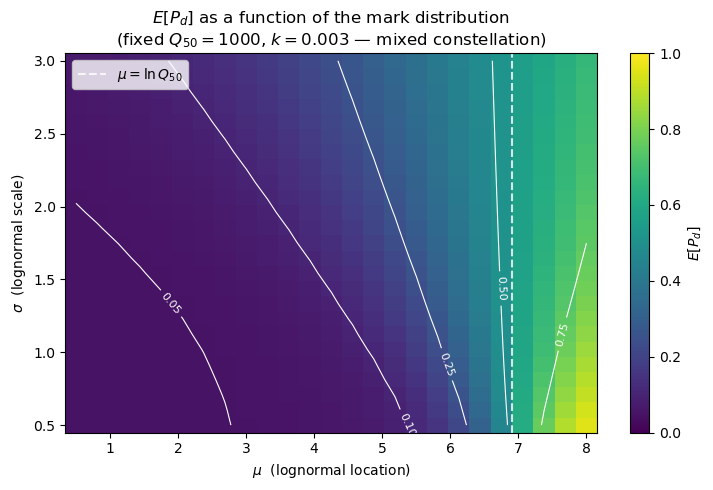

In [7]:
mus = np.linspace(0.5, 8.0, 25)
sigmas = np.linspace(0.5, 3.0, 25)
MU, SIGMA = np.meshgrid(mus, sigmas, indexing="ij")
E_PD = np.zeros_like(MU)

Q_50_const, k_const = 1000.0, 0.003

for i, mu in enumerate(mus):
    for j, sigma in enumerate(sigmas):
        E_PD[i, j] = compute_E_Pd(mu, sigma, Q_50=Q_50_const, k=k_const, n_quad=4000)

fig, ax = plt.subplots(figsize=(7.5, 5))
pcm = ax.pcolormesh(MU, SIGMA, E_PD, cmap="viridis", shading="auto", vmin=0, vmax=1)
cs = ax.contour(MU, SIGMA, E_PD, levels=[0.05, 0.1, 0.25, 0.5, 0.75], colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")
ax.axvline(np.log(Q_50_const), color="white", ls="--", alpha=0.8, label="$\\mu = \\ln Q_{50}$")
ax.set_xlabel("$\\mu$  (lognormal location)")
ax.set_ylabel("$\\sigma$  (lognormal scale)")
ax.set_title(f"$E[P_d]$ as a function of the mark distribution\n"
             f"(fixed $Q_{{50}}={Q_50_const:.0f}$, $k={k_const}$ — mixed constellation)")
ax.legend(loc="upper left")
fig.colorbar(pcm, ax=ax, label="$E[P_d]$")
fig.tight_layout()
plt.show()

## Takeaways

- The paradox is not a bug in any particular satellite — it is a mathematical consequence of running a *size-dependent* filter over a *heavy-tailed* mark distribution.
- A single scalar $E[P_d]$ governs the severity: small $E[P_d]$ means large MMSF.
- Any operational inference built from satellite plume tallies must be debiased with a filter-aware model (next notebooks).
- The companion notebooks `06_stationary_numpyro_mcmc` and (pending) `07_pod_fitting_mcmc` show how to invert this filter via NumPyro.